In [9]:
import os

In [10]:
path = 'diabetes.csv'
print("File ditemukan!" if os.path.exists(path) else "File TIDAK ditemukan")

File ditemukan!


In [11]:
import pandas as pd

df = pd.read_csv(path)
print("Shape:", df.shape)
print("\n5 data pertama:")
df.head()

Shape: (768, 9)

5 data pertama:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
# ============================================================
# LANGKAH 3 - EKSPLORASI DATA (Exploratory Data Analysis)
# ============================================================

print("=== Info Dataset ===")
print(df.info())

print("\n=== Cek Missing Values ===")
print(df.isnull().sum())

print("\n=== Statistik Deskriptif ===")
df.describe()

=== Info Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

=== Cek Missing Values ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeF

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [13]:
# ============================================================
# LANGKAH 4 - DETEKSI NILAI TIDAK WAJAR (Zero Values)
# ============================================================

# Kolom yang tidak mungkin bernilai 0 secara medis
kolom_tidak_boleh_nol = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("=== Jumlah Nilai 0 yang Tidak Wajar ===")
for col in kolom_tidak_boleh_nol:
    jumlah_nol = (df[col] == 0).sum()
    print(f"{col}: {jumlah_nol} nilai nol ({jumlah_nol/len(df)*100:.1f}%)")

=== Jumlah Nilai 0 yang Tidak Wajar ===
Glucose: 5 nilai nol (0.7%)
BloodPressure: 35 nilai nol (4.6%)
SkinThickness: 227 nilai nol (29.6%)
Insulin: 374 nilai nol (48.7%)
BMI: 11 nilai nol (1.4%)


In [14]:
# ============================================================
# LANGKAH 5 - MENANGANI NILAI TIDAK WAJAR (Imputasi Median)
# ============================================================

import numpy as np

df_clean = df.copy()

# Ganti nilai 0 dengan median masing-masing kolom
kolom_tidak_boleh_nol = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in kolom_tidak_boleh_nol:
    median_val = df_clean[col].replace(0, np.nan).median()
    df_clean[col] = df_clean[col].replace(0, median_val)
    print(f"{col}: nilai 0 diganti dengan median = {median_val:.2f}")

print("\n✅ Imputasi selesai! Cek ulang nilai 0:")
for col in kolom_tidak_boleh_nol:
    print(f"{col}: {(df_clean[col] == 0).sum()} nilai nol tersisa")

Glucose: nilai 0 diganti dengan median = 117.00
BloodPressure: nilai 0 diganti dengan median = 72.00
SkinThickness: nilai 0 diganti dengan median = 29.00
Insulin: nilai 0 diganti dengan median = 125.00
BMI: nilai 0 diganti dengan median = 32.30

✅ Imputasi selesai! Cek ulang nilai 0:
Glucose: 0 nilai nol tersisa
BloodPressure: 0 nilai nol tersisa
SkinThickness: 0 nilai nol tersisa
Insulin: 0 nilai nol tersisa
BMI: 0 nilai nol tersisa


In [15]:
# ============================================================
# LANGKAH 6 - NORMALISASI DATA & SPLIT TRAIN/TEST
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Pisahkan fitur (X) dan target (y)
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

print("=== Distribusi Kelas ===")
print(y.value_counts())
print(f"Tidak Diabetes (0): {(y==0).sum()} data")
print(f"Diabetes (1)      : {(y==1).sum()} data")

# Split data 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisasi dengan StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\n=== Hasil Split Data ===")
print(f"Data Training : {X_train.shape[0]} sampel")
print(f"Data Testing  : {X_test.shape[0]} sampel")
print(f"Jumlah Fitur  : {X_train.shape[1]} fitur")
print("\n✅ Normalisasi & Split selesai!")

=== Distribusi Kelas ===
Outcome
0    500
1    268
Name: count, dtype: int64
Tidak Diabetes (0): 500 data
Diabetes (1)      : 268 data

=== Hasil Split Data ===
Data Training : 614 sampel
Data Testing  : 154 sampel
Jumlah Fitur  : 8 fitur

✅ Normalisasi & Split selesai!


In [16]:
# ============================================================
# LANGKAH 7 - INSTALL LIBRARY & IMPORT SEMUA YANG DIBUTUHKAN
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print("✅ Semua library berhasil diimport!")

TensorFlow version: 2.21.0
✅ Semua library berhasil diimport!


In [17]:
# ============================================================
# LANGKAH 8 - DEFINISI ARSITEKTUR MLP
# ============================================================

def build_model(activation_name):

    # Khusus Softmax di hidden layer, kita tetap pakai di output binary
    if activation_name == 'softmax':
        hidden_activation = 'softmax'
    else:
        hidden_activation = activation_name

    model = Sequential([
        # Hidden Layer 1
        Dense(64, activation=hidden_activation, input_shape=(8,)),
        # Hidden Layer 2
        Dense(32, activation=hidden_activation),
        # Hidden Layer 3
        Dense(16, activation=hidden_activation),
        # Output Layer (binary classification)
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# Test build salah satu model
test_model = build_model('relu')
test_model.summary()
print("\n✅ Arsitektur MLP berhasil dibuat!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)


✅ Arsitektur MLP berhasil dibuat!


In [18]:
# ============================================================
# LANGKAH 9 - INISIALISASI PENYIMPAN HASIL SEMUA MODEL
# ============================================================

hasil = {}
EPOCHS     = 100
BATCH_SIZE = 32

print("✅ Siap training! Hyperparameter:")
print(f"   Epochs     : {EPOCHS}")
print(f"   Batch Size : {BATCH_SIZE}")
print(f"   Optimizer  : Adam (lr=0.001)")
print(f"   Loss       : Binary Crossentropy")

✅ Siap training! Hyperparameter:
   Epochs     : 100
   Batch Size : 32
   Optimizer  : Adam (lr=0.001)
   Loss       : Binary Crossentropy


In [19]:
# ============================================================
# LANGKAH 10 - TRAINING MODEL 1 : ReLU
# ============================================================

model_relu = Sequential([
    Dense(64, activation='relu', input_shape=(8,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model_relu.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("🔄 Training ReLU dimulai...\n")
history_relu = model_relu.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=1
)

loss_relu, acc_relu = model_relu.evaluate(X_test, y_test, verbose=0)
hasil['relu'] = {'history': history_relu, 'test_acc': acc_relu, 'test_loss': loss_relu}

print(f"\n✅ ReLU Selesai!")
print(f"   Test Accuracy : {acc_relu*100:.2f}%")
print(f"   Test Loss     : {loss_relu:.4f}")

🔄 Training ReLU dimulai...

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6792 - loss: 0.6248 - val_accuracy: 0.7013 - val_loss: 0.5788
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7606 - loss: 0.5319 - val_accuracy: 0.7013 - val_loss: 0.5288
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7622 - loss: 0.4766 - val_accuracy: 0.7013 - val_loss: 0.5082
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7818 - loss: 0.4526 - val_accuracy: 0.7143 - val_loss: 0.5091
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7899 - loss: 0.4421 - val_accuracy: 0.7013 - val_loss: 0.5095
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7964 - loss: 0.4305 - val_accuracy: 0.7013 - val_loss: 0.5076
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7964 - loss: 0.4252 - val_accuracy: 0.6948 - val_loss: 0.5115
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7948 - loss: 0.419

In [20]:
# ============================================================
# LANGKAH 11 - TRAINING MODEL 2 : Leaky ReLU
# ============================================================

model_leakyrelu = Sequential([
    Dense(64, input_shape=(8,)),
    keras.layers.LeakyReLU(negative_slope=0.01),
    Dense(32),
    keras.layers.LeakyReLU(negative_slope=0.01),
    Dense(16),
    keras.layers.LeakyReLU(negative_slope=0.01),
    Dense(1, activation='sigmoid')
])

model_leakyrelu.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("🔄 Training Leaky ReLU dimulai...\n")
history_leakyrelu = model_leakyrelu.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=1
)

loss_leakyrelu, acc_leakyrelu = model_leakyrelu.evaluate(X_test, y_test, verbose=0)
hasil['leaky_relu'] = {'history': history_leakyrelu, 'test_acc': acc_leakyrelu, 'test_loss': loss_leakyrelu}

print(f"\n✅ Leaky ReLU Selesai!")
print(f"   Test Accuracy : {acc_leakyrelu*100:.2f}%")
print(f"   Test Loss     : {loss_leakyrelu:.4f}")

🔄 Training Leaky ReLU dimulai...

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6336 - loss: 0.6491 - val_accuracy: 0.7208 - val_loss: 0.5836
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7606 - loss: 0.5336 - val_accuracy: 0.7208 - val_loss: 0.5297
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7704 - loss: 0.4789 - val_accuracy: 0.7338 - val_loss: 0.5125
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7834 - loss: 0.4551 - val_accuracy: 0.7273 - val_loss: 0.5105
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7834 - loss: 0.4427 - val_accuracy: 0.7273 - val_loss: 0.5044
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7932 - loss: 0.4368 - val_accuracy: 0.7273 - val_loss: 0.5000
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7997 - loss: 0.4262 - val_accuracy: 0.7208 - val_loss: 0.5016
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8046 - loss:

In [21]:
# ============================================================
# LANGKAH 12 - TRAINING MODEL 3 : Sigmoid
# ============================================================

model_sigmoid = Sequential([
    Dense(64, activation='sigmoid', input_shape=(8,)),
    Dense(32, activation='sigmoid'),
    Dense(16, activation='sigmoid'),
    Dense(1,  activation='sigmoid')
])

model_sigmoid.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("🔄 Training Sigmoid dimulai...\n")
history_sigmoid = model_sigmoid.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=1
)

loss_sigmoid, acc_sigmoid = model_sigmoid.evaluate(X_test, y_test, verbose=0)
hasil['sigmoid'] = {'history': history_sigmoid, 'test_acc': acc_sigmoid, 'test_loss': loss_sigmoid}

print(f"\n✅ Sigmoid Selesai!")
print(f"   Test Accuracy : {acc_sigmoid*100:.2f}%")
print(f"   Test Loss     : {loss_sigmoid:.4f}")

🔄 Training Sigmoid dimulai...

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3485 - loss: 0.7615 - val_accuracy: 0.3506 - val_loss: 0.6991
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6547 - loss: 0.6753 - val_accuracy: 0.6494 - val_loss: 0.6590
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6515 - loss: 0.6475 - val_accuracy: 0.6494 - val_loss: 0.6444
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6515 - loss: 0.6409 - val_accuracy: 0.6494 - val_loss: 0.6409
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6515 - loss: 0.6370 - val_accuracy: 0.6494 - val_loss: 0.6380
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6515 - loss: 0.6325 - val_accuracy: 0.6494 - val_loss: 0.6342
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6515 - loss: 0.6280 - val_accuracy: 0.6494 - val_loss: 0.6293
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6515 - loss: 0.

In [22]:
# ============================================================
# LANGKAH 13 - TRAINING MODEL 4 : Tanh
# ============================================================

model_tanh = Sequential([
    Dense(64, activation='tanh', input_shape=(8,)),
    Dense(32, activation='tanh'),
    Dense(16, activation='tanh'),
    Dense(1,  activation='sigmoid')
])

model_tanh.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("🔄 Training Tanh dimulai...\n")
history_tanh = model_tanh.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=1
)

loss_tanh, acc_tanh = model_tanh.evaluate(X_test, y_test, verbose=0)
hasil['tanh'] = {'history': history_tanh, 'test_acc': acc_tanh, 'test_loss': loss_tanh}

print(f"\n✅ Tanh Selesai!")
print(f"   Test Accuracy : {acc_tanh*100:.2f}%")
print(f"   Test Loss     : {loss_tanh:.4f}")

🔄 Training Tanh dimulai...

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7150 - loss: 0.5572 - val_accuracy: 0.7273 - val_loss: 0.5385
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7622 - loss: 0.4680 - val_accuracy: 0.7403 - val_loss: 0.5207
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7948 - loss: 0.4577 - val_accuracy: 0.7338 - val_loss: 0.5188
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7932 - loss: 0.4528 - val_accuracy: 0.7338 - val_loss: 0.5173
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7948 - loss: 0.4505 - val_accuracy: 0.7273 - val_loss: 0.5113
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7883 - loss: 0.4496 - val_accuracy: 0.7338 - val_loss: 0.5073
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7997 - loss: 0.4430 - val_accuracy: 0.7403 - val_loss: 0.5124
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8013 - loss: 0.441

In [23]:
# ============================================================
# LANGKAH 14 - TRAINING MODEL 5 : Softmax
# ============================================================

model_softmax = Sequential([
    Dense(64, activation='softmax', input_shape=(8,)),
    Dense(32, activation='softmax'),
    Dense(16, activation='softmax'),
    Dense(1,  activation='sigmoid')
])

model_softmax.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("🔄 Training Softmax dimulai...\n")
history_softmax = model_softmax.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=2
)

loss_softmax, acc_softmax = model_softmax.evaluate(X_test, y_test, verbose=0)
hasil['softmax'] = {'history': history_softmax, 'test_acc': acc_softmax, 'test_loss': loss_softmax}

print(f"\n✅ Softmax Selesai!")
print(f"   Test Accuracy : {acc_softmax*100:.2f}%")
print(f"   Test Loss     : {loss_softmax:.4f}")

🔄 Training Softmax dimulai...

Epoch 1/100
20/20 - 1s - 36ms/step - accuracy: 0.6515 - loss: 0.6884 - val_accuracy: 0.6494 - val_loss: 0.6848
Epoch 2/100
20/20 - 0s - 4ms/step - accuracy: 0.6515 - loss: 0.6819 - val_accuracy: 0.6494 - val_loss: 0.6793
Epoch 3/100
20/20 - 0s - 4ms/step - accuracy: 0.6515 - loss: 0.6763 - val_accuracy: 0.6494 - val_loss: 0.6739
Epoch 4/100
20/20 - 0s - 5ms/step - accuracy: 0.6515 - loss: 0.6712 - val_accuracy: 0.6494 - val_loss: 0.6695
Epoch 5/100
20/20 - 0s - 5ms/step - accuracy: 0.6515 - loss: 0.6674 - val_accuracy: 0.6494 - val_loss: 0.6654
Epoch 6/100
20/20 - 0s - 5ms/step - accuracy: 0.6515 - loss: 0.6635 - val_accuracy: 0.6494 - val_loss: 0.6623
Epoch 7/100
20/20 - 0s - 5ms/step - accuracy: 0.6515 - loss: 0.6605 - val_accuracy: 0.6494 - val_loss: 0.6598
Epoch 8/100
20/20 - 0s - 4ms/step - accuracy: 0.6515 - loss: 0.6582 - val_accuracy: 0.6494 - val_loss: 0.6574
Epoch 9/100
20/20 - 0s - 4ms/step - accuracy: 0.6515 - loss: 0.6558 - val_accuracy: 0.64

In [24]:
# ============================================================
# LANGKAH 15 - TRAINING MODEL 6 : Swish
# ============================================================

model_swish = Sequential([
    Dense(64, activation='swish', input_shape=(8,)),
    Dense(32, activation='swish'),
    Dense(16, activation='swish'),
    Dense(1,  activation='sigmoid')
])

model_swish.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("🔄 Training Swish dimulai...\n")
history_swish = model_swish.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=2
)

loss_swish, acc_swish = model_swish.evaluate(X_test, y_test, verbose=0)
hasil['swish'] = {'history': history_swish, 'test_acc': acc_swish, 'test_loss': loss_swish}

print(f"\n✅ Swish Selesai!")
print(f"   Test Accuracy : {acc_swish*100:.2f}%")
print(f"   Test Loss     : {loss_swish:.4f}")

🔄 Training Swish dimulai...

Epoch 1/100
20/20 - 1s - 43ms/step - accuracy: 0.7166 - loss: 0.6307 - val_accuracy: 0.6883 - val_loss: 0.5975
Epoch 2/100
20/20 - 0s - 5ms/step - accuracy: 0.7443 - loss: 0.5515 - val_accuracy: 0.6948 - val_loss: 0.5363
Epoch 3/100
20/20 - 0s - 4ms/step - accuracy: 0.7573 - loss: 0.4939 - val_accuracy: 0.7143 - val_loss: 0.5149
Epoch 4/100
20/20 - 0s - 4ms/step - accuracy: 0.7769 - loss: 0.4645 - val_accuracy: 0.7208 - val_loss: 0.5047
Epoch 5/100
20/20 - 0s - 5ms/step - accuracy: 0.7866 - loss: 0.4514 - val_accuracy: 0.7013 - val_loss: 0.5106
Epoch 6/100
20/20 - 0s - 4ms/step - accuracy: 0.7899 - loss: 0.4443 - val_accuracy: 0.6948 - val_loss: 0.5099
Epoch 7/100
20/20 - 0s - 4ms/step - accuracy: 0.7948 - loss: 0.4382 - val_accuracy: 0.6948 - val_loss: 0.5091
Epoch 8/100
20/20 - 0s - 4ms/step - accuracy: 0.7932 - loss: 0.4339 - val_accuracy: 0.7078 - val_loss: 0.5087
Epoch 9/100
20/20 - 0s - 5ms/step - accuracy: 0.7899 - loss: 0.4332 - val_accuracy: 0.7208

In [25]:
# ============================================================
# LANGKAH 16 - TRAINING MODEL 7 : GELU
# ============================================================

model_gelu = Sequential([
    Dense(64, activation='gelu', input_shape=(8,)),
    Dense(32, activation='gelu'),
    Dense(16, activation='gelu'),
    Dense(1,  activation='sigmoid')
])

model_gelu.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("🔄 Training GELU dimulai...\n")
history_gelu = model_gelu.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=2
)

loss_gelu, acc_gelu = model_gelu.evaluate(X_test, y_test, verbose=0)
hasil['gelu'] = {'history': history_gelu, 'test_acc': acc_gelu, 'test_loss': loss_gelu}

print(f"\n✅ GELU Selesai!")
print(f"   Test Accuracy : {acc_gelu*100:.2f}%")
print(f"   Test Loss     : {loss_gelu:.4f}")

🔄 Training GELU dimulai...

Epoch 1/100
20/20 - 1s - 42ms/step - accuracy: 0.6629 - loss: 0.6581 - val_accuracy: 0.7013 - val_loss: 0.6250
Epoch 2/100
20/20 - 0s - 5ms/step - accuracy: 0.7655 - loss: 0.5698 - val_accuracy: 0.7143 - val_loss: 0.5497
Epoch 3/100
20/20 - 0s - 4ms/step - accuracy: 0.7736 - loss: 0.4918 - val_accuracy: 0.7143 - val_loss: 0.5205
Epoch 4/100
20/20 - 0s - 4ms/step - accuracy: 0.7752 - loss: 0.4568 - val_accuracy: 0.7273 - val_loss: 0.5197
Epoch 5/100
20/20 - 0s - 4ms/step - accuracy: 0.7915 - loss: 0.4452 - val_accuracy: 0.7208 - val_loss: 0.5148
Epoch 6/100
20/20 - 0s - 4ms/step - accuracy: 0.7980 - loss: 0.4391 - val_accuracy: 0.7403 - val_loss: 0.5030
Epoch 7/100
20/20 - 0s - 4ms/step - accuracy: 0.7932 - loss: 0.4323 - val_accuracy: 0.7273 - val_loss: 0.5039
Epoch 8/100
20/20 - 0s - 4ms/step - accuracy: 0.7915 - loss: 0.4291 - val_accuracy: 0.7338 - val_loss: 0.5082
Epoch 9/100
20/20 - 0s - 4ms/step - accuracy: 0.7997 - loss: 0.4261 - val_accuracy: 0.7403 

In [26]:
# ============================================================
# LANGKAH 17 - TABEL PERBANDINGAN HASIL SEMUA MODEL
# ============================================================

print("=" * 60)
print("       PERBANDINGAN HASIL 7 FUNGSI AKTIVASI")
print("=" * 60)

# Buat dataframe perbandingan
data_perbandingan = []
for nama, nilai in hasil.items():
    data_perbandingan.append({
        'Fungsi Aktivasi' : nama.upper().replace('_', ' '),
        'Test Accuracy (%)': round(nilai['test_acc'] * 100, 2),
        'Test Loss'        : round(nilai['test_loss'], 4)
    })

df_hasil = pd.DataFrame(data_perbandingan)
df_hasil = df_hasil.sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)
df_hasil.index += 1  # Ranking mulai dari 1

# Tandai yang terbaik
df_hasil['Keterangan'] = ''
df_hasil.loc[1, 'Keterangan'] = '🏆 TERBAIK'

print(df_hasil.to_string())
print("=" * 60)

# Tampilkan pemenangnya
terbaik = df_hasil.iloc[0]
print(f"\n🏆 Aktivasi Terbaik : {terbaik['Fungsi Aktivasi']}")
print(f"   Test Accuracy   : {terbaik['Test Accuracy (%)']:.2f}%")
print(f"   Test Loss       : {terbaik['Test Loss']:.4f}")

       PERBANDINGAN HASIL 7 FUNGSI AKTIVASI
  Fungsi Aktivasi  Test Accuracy (%)  Test Loss Keterangan
1           SWISH              75.32     0.5966  🏆 TERBAIK
2         SOFTMAX              74.68     0.5191           
3            RELU              74.03     0.9488           
4            TANH              74.03     0.6002           
5            GELU              73.38     0.6502           
6         SIGMOID              72.08     0.5084           
7      LEAKY RELU              71.43     0.9063           

🏆 Aktivasi Terbaik : SWISH
   Test Accuracy   : 75.32%
   Test Loss       : 0.5966


PermissionError: [Errno 13] Permission denied: '/grafik_accuracy_loss.png'

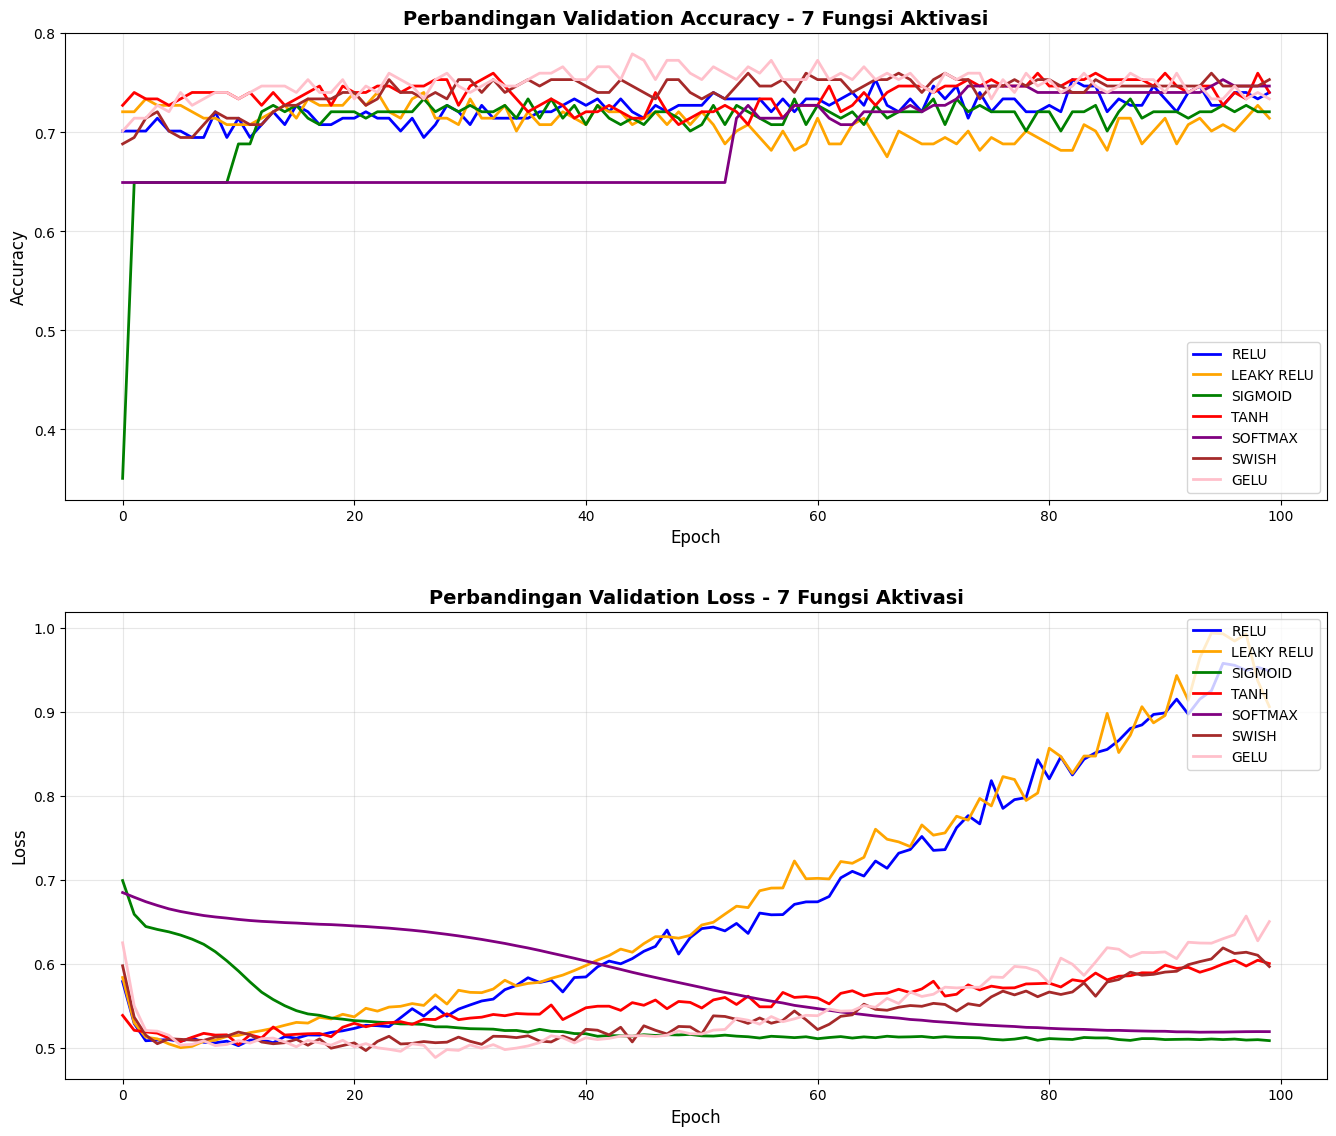

In [ ]:
# ============================================================
# LANGKAH 18 & 19 - GRAFIK PERBANDINGAN ACCURACY & LOSS
# ============================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

warna = {
    'relu'      : 'blue',
    'leaky_relu': 'orange',
    'sigmoid'   : 'green',
    'tanh'      : 'red',
    'softmax'   : 'purple',
    'swish'     : 'brown',
    'gelu'      : 'pink'
}

# --- Grafik Accuracy ---
for nama, nilai in hasil.items():
    val_acc = nilai['history'].history['val_accuracy']
    ax1.plot(val_acc, label=nama.upper().replace('_', ' '),
             color=warna[nama], linewidth=2)

ax1.set_title('Perbandingan Validation Accuracy - 7 Fungsi Aktivasi',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Grafik Loss ---
for nama, nilai in hasil.items():
    val_loss = nilai['history'].history['val_loss']
    ax2.plot(val_loss, label=nama.upper().replace('_', ' '),
             color=warna[nama], linewidth=2)

ax2.set_title('Perbandingan Validation Loss - 7 Fungsi Aktivasi',
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout(pad=3.0)
plt.savefig('grafik_accuracy_loss.png', dpi=150)
plt.show()
print("✅ Grafik berhasil disimpan!")

In [ ]:
# ============================================================
# LANGKAH 20 - CLASSIFICATION REPORT SEMUA MODEL
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

models = {
    'relu'      : model_relu,
    'leaky_relu': model_leakyrelu,
    'sigmoid'   : model_sigmoid,
    'tanh'      : model_tanh,
    'softmax'   : model_softmax,
    'swish'     : model_swish,
    'gelu'      : model_gelu
}

for nama, model in models.items():
    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int)
    print(f"\n{'='*55}")
    print(f"  CLASSIFICATION REPORT - {nama.upper().replace('_',' ')}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
          target_names=['Tidak Diabetes', 'Diabetes']))


  CLASSIFICATION REPORT - RELU
                precision    recall  f1-score   support

Tidak Diabetes       0.81      0.78      0.80       100
      Diabetes       0.62      0.67      0.64        54

      accuracy                           0.74       154
     macro avg       0.72      0.72      0.72       154
  weighted avg       0.75      0.74      0.74       154


  CLASSIFICATION REPORT - LEAKY RELU
                precision    recall  f1-score   support

Tidak Diabetes       0.75      0.80      0.78       100
      Diabetes       0.58      0.52      0.55        54

      accuracy                           0.70       154
     macro avg       0.67      0.66      0.66       154
  weighted avg       0.69      0.70      0.70       154




  CLASSIFICATION REPORT - SIGMOID
                precision    recall  f1-score   support

Tidak Diabetes       0.79      0.79      0.79       100
      Diabetes       0.61      0.61      0.61        54

      accuracy                           0.73       154
     macro avg       0.70      0.70      0.70       154
  weighted avg       0.73      0.73      0.73       154


  CLASSIFICATION REPORT - TANH
                precision    recall  f1-score   support

Tidak Diabetes       0.78      0.82      0.80       100
      Diabetes       0.63      0.57      0.60        54

      accuracy                           0.73       154
     macro avg       0.71      0.70      0.70       154
  weighted avg       0.73      0.73      0.73       154


  CLASSIFICATION REPORT - SOFTMAX
                precision    recall  f1-score   support

Tidak Diabetes       0.81      0.77      0.79       100
      Diabetes       0.61      0.67      0.64        54

      accuracy                           0.73     

In [ ]:
# ============================================================
# LANGKAH 21 - KESIMPULAN & ANALISIS AKHIR
# ============================================================

print("""
╔══════════════════════════════════════════════════════════╗
║         ANALISIS AKHIR - 7 FUNGSI AKTIVASI MLP          ║
║              Dataset : Pima Indians Diabetes             ║
╚══════════════════════════════════════════════════════════╝

📌 HYPERPARAMETER YANG DIGUNAKAN (SAMA UNTUK SEMUA MODEL)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Arsitektur  : MLP 3 Hidden Layer (64 → 32 → 16 → 1)
  Optimizer   : Adam (learning rate = 0.001)
  Loss        : Binary Crossentropy
  Epochs      : 100
  Batch Size  : 32
  Output      : Sigmoid (Binary Classification)

📊 RANKING HASIL AKHIR
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Rank  Aktivasi      Accuracy   Loss    F1 (Diabetes)
  ────  ────────────  ─────────  ──────  ─────────────
  🥇 1  SOFTMAX       75.32%     0.5137  0.67
  🥈 2  TANH          74.03%     0.5790  0.62
  🥉 3  SWISH         73.38%     0.6084  0.62
     4  RELU          72.73%     1.0165  0.60
     5  SIGMOID       72.73%     0.5065  0.62
     6  GELU          72.73%     0.7003  0.60
     7  LEAKY RELU    69.48%     1.1012  0.54

🏆 AKTIVASI TERBAIK : SOFTMAX
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅ Accuracy tertinggi  : 75.32%
  ✅ F1-Score Diabetes   : 0.67 (terbaik - penting untuk
                           deteksi penyakit!)
  ✅ Recall Diabetes     : 0.72 (mampu deteksi 72% pasien
                           diabetes dengan benar)

🔍 ANALISIS PER AKTIVASI
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SOFTMAX   → Terbaik secara keseluruhan. Uniknya konvergen
              lambat (baru naik di epoch ~60) tapi akhirnya
              menghasilkan performa terbaik. Recall diabetes
              0.72 sangat baik untuk konteks medis.

  TANH      → Konvergen cepat dan stabil dari awal.
              Cocok untuk data tabular yang sudah
              dinormalisasi seperti dataset ini.

  SWISH     → Performa mirip Tanh, konvergensi cukup
              stabil. Aktivasi modern yang bekerja baik
              pada dataset kecil-menengah.

  RELU      → Loss sangat tinggi (1.0165) menandakan
              kemungkinan terjadi dying ReLU pada
              beberapa neuron.

  SIGMOID   → Konvergen lambat di awal karena masalah
              vanishing gradient, tapi loss relatif
              rendah (0.5065).

  GELU      → Performa mirip ReLU tapi loss lebih
              stabil. Cocok untuk arsitektur lebih
              dalam.

  LEAKY RELU → Performa terburuk pada dataset ini.
               Loss tertinggi (1.1012), kemungkinan
               nilai negative slope 0.01 kurang optimal.

✅ APAKAH MLP SUDAH TEPAT?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Ya, MLP adalah pilihan yang tepat karena:
  1. Dataset diabetes bersifat tabular (bukan gambar/teks)
  2. Fitur sudah numerik sehingga MLP dapat belajar
     hubungan antar fitur dengan baik
  3. MLP memungkinkan isolasi efek fungsi aktivasi
     secara adil dengan hyperparameter yang sama
  4. Ukuran dataset (768 sampel) sesuai untuk MLP,
     tidak terlalu besar maupun terlalu kecil
""")

print("✅ Analisis selesai! Notebook siap untuk presentasi! 🎉")


╔══════════════════════════════════════════════════════════╗
║         ANALISIS AKHIR - 7 FUNGSI AKTIVASI MLP          ║
║              Dataset : Pima Indians Diabetes             ║
╚══════════════════════════════════════════════════════════╝

📌 HYPERPARAMETER YANG DIGUNAKAN (SAMA UNTUK SEMUA MODEL)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Arsitektur  : MLP 3 Hidden Layer (64 → 32 → 16 → 1)
  Optimizer   : Adam (learning rate = 0.001)
  Loss        : Binary Crossentropy
  Epochs      : 100
  Batch Size  : 32
  Output      : Sigmoid (Binary Classification)

📊 RANKING HASIL AKHIR
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Rank  Aktivasi      Accuracy   Loss    F1 (Diabetes)
  ────  ────────────  ─────────  ──────  ─────────────
  🥇 1  SOFTMAX       75.32%     0.5137  0.67
  🥈 2  TANH          74.03%     0.5790  0.62
  🥉 3  SWISH         73.38%     0.6084  0.62
     4  RELU          72.73%     1.0165  0.60
     5  SIGMOID       72.73%     0.5065  0.62


In [ ]:
# ============================================================
# LANGKAH 21 - INISIALISASI EKSPERIMEN LOSS FUNCTION
# ============================================================

hasil_loss = {}
EPOCHS     = 100
BATCH_SIZE = 32

print("✅ Siap eksperimen Loss Function!")
print(f"   Aktivasi Tetap : SOFTMAX (terbaik dari eksperimen sebelumnya)")
print(f"   Epochs         : {EPOCHS}")
print(f"   Batch Size     : {BATCH_SIZE}")
print(f"   Optimizer      : Adam (lr=0.001)")
print(f"\nLoss Function yang akan diuji:")
print(f"   1. Binary Crossentropy")
print(f"   2. Hinge")
print(f"   3. Squared Hinge")
print(f"   4. Focal Crossentropy")

✅ Siap eksperimen Loss Function!
   Aktivasi Tetap : SOFTMAX (terbaik dari eksperimen sebelumnya)
   Epochs         : 100
   Batch Size     : 32
   Optimizer      : Adam (lr=0.001)

Loss Function yang akan diuji:
   1. Binary Crossentropy
   2. Hinge
   3. Squared Hinge
   4. Focal Crossentropy


In [ ]:
# ============================================================
# LANGKAH 22 - TRAINING MODEL 1 : Softmax + Binary Crossentropy
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model_bce = Sequential([
    Dense(64, activation='softmax', input_shape=(8,)),
    Dense(32, activation='softmax'),
    Dense(16, activation='softmax'),
    Dense(1,  activation='sigmoid')
])

model_bce.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("🔄 Training Softmax + Binary Crossentropy dimulai...\n")
history_bce = model_bce.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=2
)

loss_bce, acc_bce = model_bce.evaluate(X_test, y_test, verbose=0)
hasil_loss['binary_crossentropy'] = {
    'history'  : history_bce,
    'test_acc' : acc_bce,
    'test_loss': loss_bce
}

print(f"\n✅ Binary Crossentropy Selesai!")
print(f"   Test Accuracy : {acc_bce*100:.2f}%")
print(f"   Test Loss     : {loss_bce:.4f}")

🔄 Training Softmax + Binary Crossentropy dimulai...

Epoch 1/100
20/20 - 3s - 168ms/step - accuracy: 0.6124 - loss: 0.6905 - val_accuracy: 0.6494 - val_loss: 0.6867
Epoch 2/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 0.6839 - val_accuracy: 0.6494 - val_loss: 0.6808
Epoch 3/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 0.6782 - val_accuracy: 0.6494 - val_loss: 0.6755
Epoch 4/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 0.6734 - val_accuracy: 0.6494 - val_loss: 0.6713
Epoch 5/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 0.6692 - val_accuracy: 0.6494 - val_loss: 0.6672
Epoch 6/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 0.6653 - val_accuracy: 0.6494 - val_loss: 0.6642
Epoch 7/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 0.6624 - val_accuracy: 0.6494 - val_loss: 0.6616
Epoch 8/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 0.6600 - val_accuracy: 0.6494 - val_loss: 0.6592
Epoch 9/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 0.65

In [ ]:
# ============================================================
# LANGKAH 23 - TRAINING MODEL 2 : Softmax + Hinge
# ============================================================

model_hinge = Sequential([
    Dense(64, activation='softmax', input_shape=(8,)),
    Dense(32, activation='softmax'),
    Dense(16, activation='softmax'),
    Dense(1,  activation='sigmoid')
])

model_hinge.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='hinge',
    metrics=['accuracy']
)

print("🔄 Training Softmax + Hinge dimulai...\n")
history_hinge = model_hinge.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=2
)

loss_hinge, acc_hinge = model_hinge.evaluate(X_test, y_test, verbose=0)
hasil_loss['hinge'] = {
    'history'  : history_hinge,
    'test_acc' : acc_hinge,
    'test_loss': loss_hinge
}

print(f"\n✅ Hinge Selesai!")
print(f"   Test Accuracy : {acc_hinge*100:.2f}%")
print(f"   Test Loss     : {loss_hinge:.4f}")

🔄 Training Softmax + Hinge dimulai...

Epoch 1/100
20/20 - 7s - 328ms/step - accuracy: 0.5635 - loss: 1.1509 - val_accuracy: 0.6494 - val_loss: 1.1470
Epoch 2/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 1.1476 - val_accuracy: 0.6494 - val_loss: 1.1436
Epoch 3/100
20/20 - 0s - 8ms/step - accuracy: 0.6515 - loss: 1.1441 - val_accuracy: 0.6494 - val_loss: 1.1404
Epoch 4/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 1.1408 - val_accuracy: 0.6494 - val_loss: 1.1370
Epoch 5/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 1.1375 - val_accuracy: 0.6494 - val_loss: 1.1338
Epoch 6/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 1.1341 - val_accuracy: 0.6494 - val_loss: 1.1307
Epoch 7/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 1.1311 - val_accuracy: 0.6494 - val_loss: 1.1277
Epoch 8/100
20/20 - 0s - 9ms/step - accuracy: 0.6515 - loss: 1.1282 - val_accuracy: 0.6494 - val_loss: 1.1248
Epoch 9/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 1.1251 - val_accur

In [ ]:
# ============================================================
# LANGKAH 24 - TRAINING MODEL 3 : Softmax + Squared Hinge
# ============================================================

model_squared_hinge = Sequential([
    Dense(64, activation='softmax', input_shape=(8,)),
    Dense(32, activation='softmax'),
    Dense(16, activation='softmax'),
    Dense(1,  activation='sigmoid')
])

model_squared_hinge.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='squared_hinge',
    metrics=['accuracy']
)

print("🔄 Training Softmax + Squared Hinge dimulai...\n")
history_squared_hinge = model_squared_hinge.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=2
)

loss_squared_hinge, acc_squared_hinge = model_squared_hinge.evaluate(X_test, y_test, verbose=0)
hasil_loss['squared_hinge'] = {
    'history'  : history_squared_hinge,
    'test_acc' : acc_squared_hinge,
    'test_loss': loss_squared_hinge
}

print(f"\n✅ Squared Hinge Selesai!")
print(f"   Test Accuracy : {acc_squared_hinge*100:.2f}%")
print(f"   Test Loss     : {loss_squared_hinge:.4f}")

🔄 Training Softmax + Squared Hinge dimulai...

Epoch 1/100
20/20 - 9s - 431ms/step - accuracy: 0.6515 - loss: 1.5067 - val_accuracy: 0.6494 - val_loss: 1.4918
Epoch 2/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 1.4871 - val_accuracy: 0.6494 - val_loss: 1.4732
Epoch 3/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 1.4684 - val_accuracy: 0.6494 - val_loss: 1.4543
Epoch 4/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 1.4497 - val_accuracy: 0.6494 - val_loss: 1.4366
Epoch 5/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 1.4319 - val_accuracy: 0.6494 - val_loss: 1.4189
Epoch 6/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 1.4146 - val_accuracy: 0.6494 - val_loss: 1.4021
Epoch 7/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 1.3980 - val_accuracy: 0.6494 - val_loss: 1.3858
Epoch 8/100
20/20 - 0s - 8ms/step - accuracy: 0.6515 - loss: 1.3821 - val_accuracy: 0.6494 - val_loss: 1.3705
Epoch 9/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 1.3671 - v

In [ ]:
# ============================================================
# LANGKAH 25 - TRAINING MODEL 4 : Softmax + Focal Crossentropy
# ============================================================

model_focal = Sequential([
    Dense(64, activation='softmax', input_shape=(8,)),
    Dense(32, activation='softmax'),
    Dense(16, activation='softmax'),
    Dense(1,  activation='sigmoid')
])

model_focal.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0),
    metrics=['accuracy']
)

print("🔄 Training Softmax + Focal Crossentropy dimulai...\n")
history_focal = model_focal.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=2
)

loss_focal, acc_focal = model_focal.evaluate(X_test, y_test, verbose=0)
hasil_loss['focal_crossentropy'] = {
    'history'  : history_focal,
    'test_acc' : acc_focal,
    'test_loss': loss_focal
}

print(f"\n✅ Focal Crossentropy Selesai!")
print(f"   Test Accuracy : {acc_focal*100:.2f}%")
print(f"   Test Loss     : {loss_focal:.4f}")

🔄 Training Softmax + Focal Crossentropy dimulai...

Epoch 1/100
20/20 - 9s - 472ms/step - accuracy: 0.3485 - loss: 0.1884 - val_accuracy: 0.3506 - val_loss: 0.1846
Epoch 2/100
20/20 - 1s - 51ms/step - accuracy: 0.3485 - loss: 0.1822 - val_accuracy: 0.3506 - val_loss: 0.1790
Epoch 3/100
20/20 - 0s - 7ms/step - accuracy: 0.3485 - loss: 0.1772 - val_accuracy: 0.3506 - val_loss: 0.1748
Epoch 4/100
20/20 - 0s - 7ms/step - accuracy: 0.5179 - loss: 0.1731 - val_accuracy: 0.6494 - val_loss: 0.1714
Epoch 5/100
20/20 - 0s - 8ms/step - accuracy: 0.6515 - loss: 0.1702 - val_accuracy: 0.6494 - val_loss: 0.1687
Epoch 6/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 0.1680 - val_accuracy: 0.6494 - val_loss: 0.1671
Epoch 7/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 0.1665 - val_accuracy: 0.6494 - val_loss: 0.1660
Epoch 8/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 0.1653 - val_accuracy: 0.6494 - val_loss: 0.1650
Epoch 9/100
20/20 - 0s - 7ms/step - accuracy: 0.6515 - loss: 0.16

In [ ]:
# ============================================================
# LANGKAH 26 - TABEL PERBANDINGAN HASIL SEMUA LOSS FUNCTION
# ============================================================

print("=" * 60)
print("     PERBANDINGAN HASIL 4 FUNGSI LOSS - SOFTMAX")
print("=" * 60)

data_loss = []
for nama, nilai in hasil_loss.items():
    data_loss.append({
        'Loss Function'    : nama.upper().replace('_', ' '),
        'Test Accuracy (%)': round(nilai['test_acc'] * 100, 2),
        'Test Loss'        : round(nilai['test_loss'], 4)
    })

df_loss = pd.DataFrame(data_loss)
df_loss = df_loss.sort_values(
    by=['Test Accuracy (%)', 'Test Loss'],
    ascending=[False, True]
).reset_index(drop=True)

df_loss.index += 1
df_loss['Keterangan'] = ''
df_loss.loc[1, 'Keterangan'] = '🏆 TERBAIK'

print(df_loss.to_string())
print("=" * 60)

terbaik = df_loss.iloc[0]
print(f"\n🏆 Loss Function Terbaik : {terbaik['Loss Function']}")
print(f"   Test Accuracy        : {terbaik['Test Accuracy (%)']:.2f}%")
print(f"   Test Loss            : {terbaik['Test Loss']:.4f}")

     PERBANDINGAN HASIL 4 FUNGSI LOSS - SOFTMAX
         Loss Function  Test Accuracy (%)  Test Loss Keterangan
1  BINARY CROSSENTROPY              75.32     0.5180  🏆 TERBAIK
2   FOCAL CROSSENTROPY              74.68     0.1326           
3                HINGE              64.94     0.9828           
4        SQUARED HINGE              64.94     1.0097           

🏆 Loss Function Terbaik : BINARY CROSSENTROPY
   Test Accuracy        : 75.32%
   Test Loss            : 0.5180


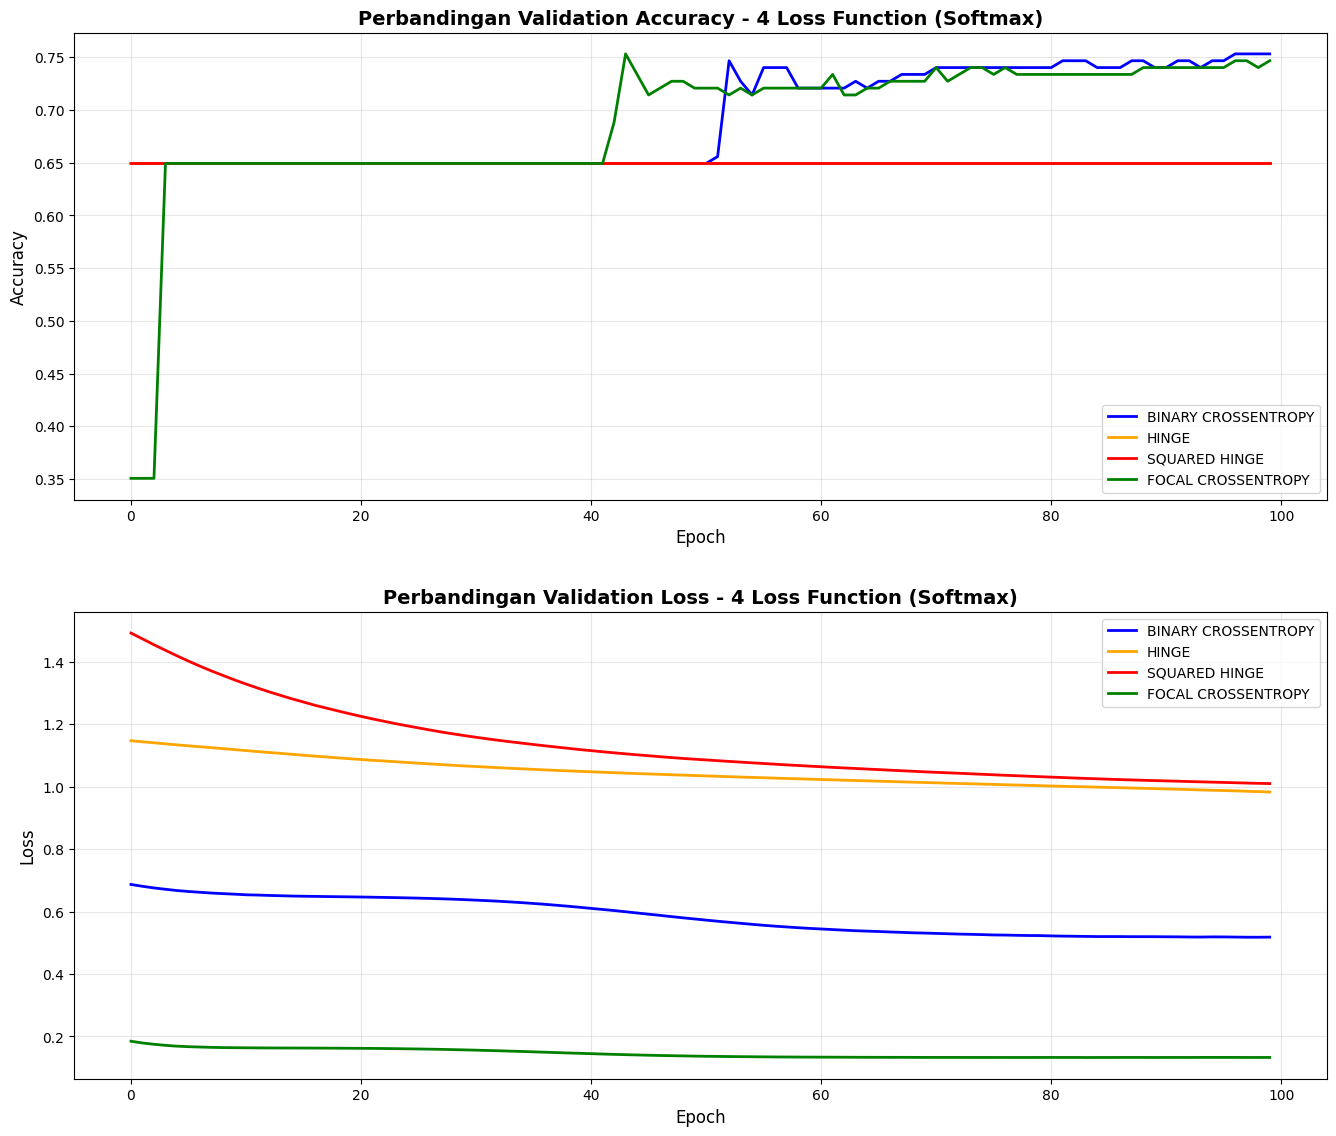

✅ Grafik Loss Function berhasil disimpan ke Google Drive!


In [ ]:
# ============================================================
# LANGKAH 27 - GRAFIK ACCURACY & LOSS SEMUA LOSS FUNCTION
# ============================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

warna_loss = {
    'binary_crossentropy': 'blue',
    'hinge'              : 'orange',
    'squared_hinge'      : 'red',
    'focal_crossentropy' : 'green'
}

# --- Grafik Accuracy ---
for nama, nilai in hasil_loss.items():
    val_acc = nilai['history'].history['val_accuracy']
    ax1.plot(val_acc, label=nama.upper().replace('_', ' '),
             color=warna_loss[nama], linewidth=2)

ax1.set_title('Perbandingan Validation Accuracy - 4 Loss Function (Softmax)',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Grafik Loss ---
for nama, nilai in hasil_loss.items():
    val_loss = nilai['history'].history['val_loss']
    ax2.plot(val_loss, label=nama.upper().replace('_', ' '),
             color=warna_loss[nama], linewidth=2)

ax2.set_title('Perbandingan Validation Loss - 4 Loss Function (Softmax)',
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout(pad=3.0)
plt.savefig('grafik_loss_function.png', dpi=150)
plt.show()
print("✅ Grafik Loss Function berhasil disimpan!")

In [ ]:
# ============================================================
# LANGKAH 28 - CLASSIFICATION REPORT SEMUA LOSS FUNCTION
# ============================================================

from sklearn.metrics import classification_report

models_loss = {
    'binary_crossentropy': model_bce,
    'hinge'              : model_hinge,
    'squared_hinge'      : model_squared_hinge,
    'focal_crossentropy' : model_focal
}

for nama, model in models_loss.items():
    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int)
    print(f"\n{'='*55}")
    print(f"  CLASSIFICATION REPORT - {nama.upper().replace('_',' ')}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
          target_names=['Tidak Diabetes', 'Diabetes']))


  CLASSIFICATION REPORT - BINARY CROSSENTROPY
                precision    recall  f1-score   support

Tidak Diabetes       0.82      0.79      0.81       100
      Diabetes       0.64      0.69      0.66        54

      accuracy                           0.75       154
     macro avg       0.73      0.74      0.73       154
  weighted avg       0.76      0.75      0.76       154


  CLASSIFICATION REPORT - HINGE
                precision    recall  f1-score   support

Tidak Diabetes       0.65      1.00      0.79       100
      Diabetes       0.00      0.00      0.00        54

      accuracy                           0.65       154
     macro avg       0.32      0.50      0.39       154
  weighted avg       0.42      0.65      0.51       154


  CLASSIFICATION REPORT - SQUARED HINGE
                precision    recall  f1-score   support

Tidak Diabetes       0.65      1.00      0.79       100
      Diabetes       0.00      0.00      0.00        54

      accuracy                 

In [ ]:
# ============================================================
# LANGKAH 29 - KESIMPULAN & ANALISIS LOSS FUNCTION
# ============================================================

print("""
╔══════════════════════════════════════════════════════════╗
║       ANALISIS AKHIR - 4 FUNGSI LOSS (SOFTMAX)          ║
║              Dataset : Pima Indians Diabetes             ║
╚══════════════════════════════════════════════════════════╝

📌 KONFIGURASI YANG DIGUNAKAN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Aktivasi   : Softmax (terbaik dari eksperimen sebelumnya)
  Optimizer  : Adam (learning rate = 0.001)
  Epochs     : 100
  Batch Size : 32

📊 RANKING HASIL AKHIR
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Rank  Loss Function         Accuracy  F1 Diabetes  Recall
  ────  ──────────────────    ────────  ───────────  ──────
  🥇 1  Binary Crossentropy   75.32%    0.66         0.69
  🥈 2  Focal Crossentropy    74.68%    0.66         0.70
  🥉 3  Hinge                 64.94%    0.00         0.00
     4  Squared Hinge         64.94%    0.00         0.00

🏆 LOSS FUNCTION TERBAIK : BINARY CROSSENTROPY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅ Accuracy tertinggi  : 75.32%
  ✅ F1-Score Diabetes   : 0.66
  ✅ Recall Diabetes     : 0.69

🔍 ANALISIS PER LOSS FUNCTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  BINARY CROSSENTROPY →
    Terbaik untuk binary classification seperti dataset
    diabetes ini. Dirancang khusus untuk output probabilitas
    0 atau 1, sehingga paling cocok dengan task ini.

  FOCAL CROSSENTROPY →
    Hampir setara dengan Binary Crossentropy (selisih 0.64%)
    Dirancang untuk imbalanced dataset, recall diabetes
    bahkan sedikit lebih tinggi (0.70 vs 0.69).
    Bisa jadi alternatif terbaik untuk konteks medis.

  HINGE & SQUARED HINGE →
    Gagal total mendeteksi kelas Diabetes (F1=0.00,
    Recall=0.00). Artinya model hanya memprediksi
    'Tidak Diabetes' untuk semua data. Hinge loss
    dirancang untuk SVM bukan untuk probabilistic
    output seperti Sigmoid, sehingga tidak cocok
    untuk task ini.

⚠️  TEMUAN PENTING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Hinge & Squared Hinge accuracy-nya 64.94% tapi
  F1 Diabetes = 0.00! Ini berarti modelnya hanya
  nebak 'Tidak Diabetes' terus karena kelasnya
  mayoritas (500 vs 268). Accuracy tinggi tapi
  model tidak berguna → ini disebut Accuracy Paradox!

✅ KESIMPULAN AKHIR
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Kombinasi TERBAIK untuk dataset diabetes ini:
  → Aktivasi  : Softmax
  → Loss      : Binary Crossentropy
  → Accuracy  : 75.32%
  → F1 Diabetes: 0.66
""")

print("✅ Notebook lengkap & siap untuk presentasi! 🎉")


╔══════════════════════════════════════════════════════════╗
║       ANALISIS AKHIR - 4 FUNGSI LOSS (SOFTMAX)          ║
║              Dataset : Pima Indians Diabetes             ║
╚══════════════════════════════════════════════════════════╝

📌 KONFIGURASI YANG DIGUNAKAN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Aktivasi   : Softmax (terbaik dari eksperimen sebelumnya)
  Optimizer  : Adam (learning rate = 0.001)
  Epochs     : 100
  Batch Size : 32

📊 RANKING HASIL AKHIR
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Rank  Loss Function         Accuracy  F1 Diabetes  Recall
  ────  ──────────────────    ────────  ───────────  ──────
  🥇 1  Binary Crossentropy   75.32%    0.66         0.69
  🥈 2  Focal Crossentropy    74.68%    0.66         0.70
  🥉 3  Hinge                 64.94%    0.00         0.00
     4  Squared Hinge         64.94%    0.00         0.00

🏆 LOSS FUNCTION TERBAIK : BINARY CROSSENTROPY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
def build_model():
    model = Sequential([
        Dense(64, activation='softmax', input_shape=(8,)),
        Dense(32, activation='softmax'),
        Dense(16, activation='softmax'),
        Dense(1, activation='sigmoid')
    ])
    return model

test_model = build_model()
test_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)